Model Performance:
MAE: 1565.31
RMSE: 2337.78


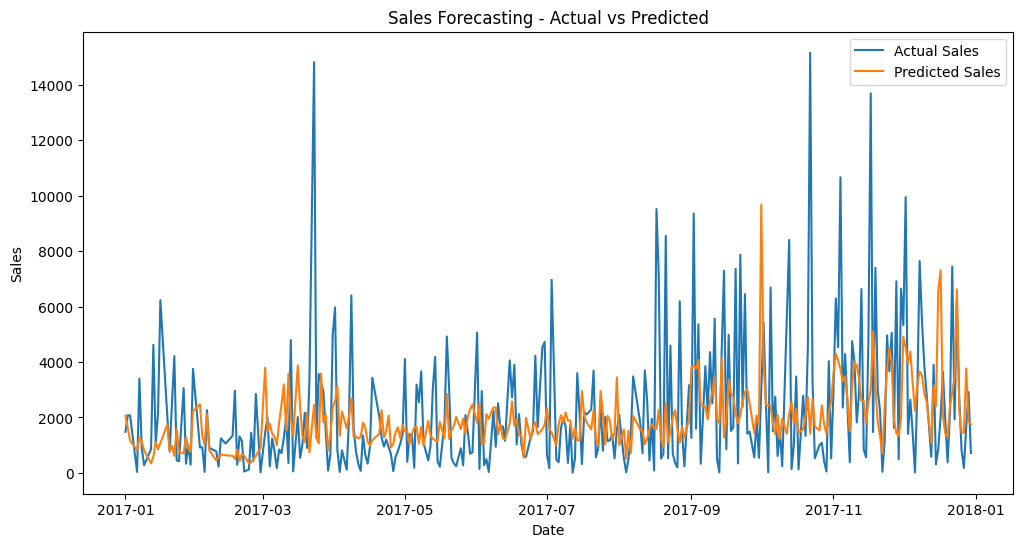


Next 30 Days Forecast:
   Order Date  Forecasted Sales
0  2017-12-31       4154.575209
1  2018-01-01       2099.689192
2  2018-01-02       2549.065482
3  2018-01-03       1127.006020
4  2018-01-04        671.761398
5  2018-01-05       1176.317636
6  2018-01-06        802.617366
7  2018-01-07        498.334180
8  2018-01-08        980.244930
9  2018-01-09        555.611640
10 2018-01-10        489.401020
11 2018-01-11        381.177610
12 2018-01-12        581.284640
13 2018-01-13        410.465120
14 2018-01-14        461.962320
15 2018-01-15        710.490380
16 2018-01-16        604.886750
17 2018-01-17        604.157340
18 2018-01-18        441.181890
19 2018-01-19        483.597940
20 2018-01-20        476.321740
21 2018-01-21        898.908940
22 2018-01-22        954.277380
23 2018-01-23        685.217140
24 2018-01-24        510.765540
25 2018-01-25        412.383200
26 2018-01-26        545.145470
27 2018-01-27        586.800830
28 2018-01-28        477.527330
29 2018-01-29   

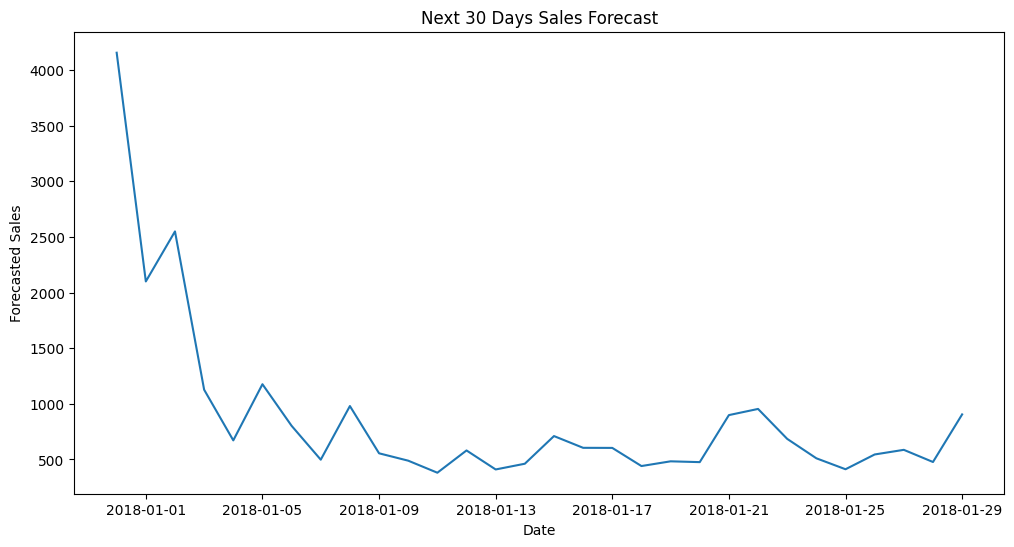

In [5]:
# ==============================
# SALES FORECASTING PROJECT
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1️⃣ Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# 2️⃣ Data Cleaning
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df[['Order Date', 'Sales']]
df = df.dropna()

# 3️⃣ Aggregate Daily Sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# 4️⃣ Feature Engineering
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

# Lag feature
daily_sales['Lag1'] = daily_sales['Sales'].shift(1)
daily_sales = daily_sales.dropna()

# 5️⃣ Train Test Split
train = daily_sales[daily_sales['Order Date'] < '2017-01-01']
test = daily_sales[daily_sales['Order Date'] >= '2017-01-01']

features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Lag1']

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

# 6️⃣ Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7️⃣ Predictions
predictions = model.predict(X_test)

# 8️⃣ Evaluation
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Model Performance:")
print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

# 9️⃣ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test['Order Date'], y_test, label="Actual Sales")
plt.plot(test['Order Date'], predictions, label="Predicted Sales")
plt.legend()
plt.title("Sales Forecasting - Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# 🔟 Forecast Next 30 Days
last_date = daily_sales['Order Date'].max()
future_dates = pd.date_range(start=last_date, periods=31, freq='D')[1:]

future_df = pd.DataFrame({'Order Date': future_dates})
future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['DayOfWeek'] = future_df['Order Date'].dt.dayofweek
future_df['Lag1'] = daily_sales['Sales'].iloc[-1]

future_predictions = model.predict(future_df[features])

future_df['Forecasted Sales'] = future_predictions

print("\nNext 30 Days Forecast:")
print(future_df[['Order Date','Forecasted Sales']])

plt.figure(figsize=(12,6))
plt.plot(future_df['Order Date'], future_df['Forecasted Sales'])
plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Forecasted Sales")
plt.show()
